# 温和放量 Q3/Q4 正斜率因子 v2 - P0 优化版

本 Notebook 在原始因子的基础上进行两项 P0 级优化：

| 优化项 | 原始版本 | P0 优化版本 |
|--------|---------|------------|
| **成交量指标** | total_turnover（成交额）原始值 | **turnover_rate（换手率）**，天然消除规模差异 |
| **中性化** | 无 | **行业中性化 + 市值中性化**，消除风格暴露 |

**核心逻辑不变**：计算成交额/换手率的斜率 -> 横截面 5 分位 -> 买入 Q3/Q4 且 slope > 0 的股票。


## 0. 环境准备

导入所需库，配置显示参数。


In [ ]:
# ============================================================
# 0. 环境准备：导入库、设置显示参数
# ============================================================

from pathlib import Path
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm  # 用于 OLS 回归做中性化

%matplotlib inline

import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Microsoft YaHei', 'SimHei']  # 按顺序回退  显示中文
# 为了坐标轴负号正常显示。matplotlib默认不支持中文，设置中文字体后，负号会显示异常。需要手动将坐标轴负号设为False才能正常显示负号。
matplotlib.rcParams['axes.unicode_minus'] = False



# 设置 pandas 显示参数
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore")

# 尝试导入 Alphalens（可选）
try:
    import alphalens as al
    HAS_ALPHALENS = True
    print("Alphalens 可用。")
except Exception as exc:
    HAS_ALPHALENS = False
    print(f"Alphalens 不可用，将使用 Pandas 分析。原因：{type(exc).__name__}: {exc}")

print("环境准备完成。")


Alphalens 可用。
环境准备完成。


## 1. 参数配置

集中管理所有参数，方便后续调整。


In [3]:
# ============================================================
# 1. Configuration
# ============================================================

DATA_DIR = Path("data_rq")
OUTPUT_DIR = Path("results/alphalens_moderate_q34_positive_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use cache metadata as the source of truth for file-name dates.
CACHE_META_PATH = DATA_DIR / "cn_stock_cache_meta.json"
if CACHE_META_PATH.exists():
    import json
    CACHE_META = json.loads(CACHE_META_PATH.read_text(encoding="utf-8"))
else:
    CACHE_META = {}

START_DATE = CACHE_META.get("start_date", "2020-01-01")
END_DATE = CACHE_META.get("end_date", "2026-04-29")
AS_OF_DATE = CACHE_META.get("as_of_date", END_DATE)
UNIVERSE_FILE = Path(CACHE_META.get("universe_file", DATA_DIR / f"cn_stock_universe_{AS_OF_DATE.replace('-', '')}.csv"))

FACTOR_WINDOW = 20
QUANTILES = 5
BUY_QUANTILES = [3, 4]
FORWARD_PERIODS = (1, 5, 10, 20)
MAX_ASSETS = None
CHUNK_SIZE = 500

print(f"Output dir: {OUTPUT_DIR.resolve()}")
print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Cache date range: {START_DATE} ~ {END_DATE}")
print(f"Universe as-of date: {AS_OF_DATE}")
print(f"Universe file: {UNIVERSE_FILE}")
print(f"Factor window: {FACTOR_WINDOW} | quantiles: {QUANTILES} | buy groups: Q{BUY_QUANTILES}")
print(f"Forward periods: {FORWARD_PERIODS}")
print(f"Max assets: {MAX_ASSETS or 'all'}")


Output dir: /home/pl_ubuntu/my_quantproject/hzbplus/results/alphalens_moderate_q34_positive_v2
Data dir: /home/pl_ubuntu/my_quantproject/hzbplus/data_rq
Cache date range: 2020-01-01 ~ 2026-05-13
Universe as-of date: 2026-05-13
Universe file: data_rq/cn_stock_universe_20260513.csv
Factor window: 20 | quantiles: 5 | buy groups: Q[3, 4]
Forward periods: (1, 5, 10, 20)
Max assets: all


## 2. Data Preparation

This notebook now expects prebuilt parquet matrices from `prepare_cn_stock_data_rq.py` under `data_rq/`.

Required inputs:
1. `close`: adjusted daily close from `rqdatac.get_price(..., adjust_type="pre")`, used for forward returns.
2. `turnover_rate`: daily turnover rate from `rqdatac.get_turnover_rate(..., fields="today", expect_df=True, market="cn")`.
3. `market_cap`: total market capitalization from `rqdatac.get_factor(..., factor="market_cap", expect_df=True, market="cn")`.
4. `cn_stock_universe_YYYYMMDD.csv`: stock universe and industry labels from `rqdatac.all_instruments(type="CS", market="cn")`.

Run the data job first:

```bash
python prepare_cn_stock_data_rq.py   --start-date 2020-01-01   --end-date 2026-04-29   --as-of-date 2026-04-29   --output-dir data_rq   --storage parquet   --turnover-field today   --market-cap-factor market_cap
```

Market-cap factor alternatives supported by RiceQuant include `market_cap_3`, `a_share_market_val_3`, and `a_share_market_val_in_circulation`. The notebook default remains `market_cap` unless the parquet cache is regenerated with another factor and saved under the same logical matrix name.

Important: this notebook no longer creates fallback z-score turnover or pseudo market cap data. Missing or suspicious parquet input should fail early.


In [4]:
# ============================================================
# 2.1 通用工具函数：路径解析、数据读取、rolling slope 计算
# ============================================================

def matrix_path(data_dir, field, start_date, end_date):
    """Return the required parquet cache path for a date x stock matrix."""
    stem = f"cn_stock_{field}_{start_date.replace('-', '')}_{end_date.replace('-', '')}"
    parquet_path = data_dir / f"{stem}.parquet"
    if parquet_path.exists():
        return parquet_path
    return None


def read_matrix(data_dir, field, start_date, end_date):
    """Read a parquet date x stock matrix and normalize index/column order."""
    path = matrix_path(data_dir, field, start_date, end_date)
    if path is None:
        stem = f"cn_stock_{field}_{start_date.replace('-', '')}_{end_date.replace('-', '')}.parquet"
        raise FileNotFoundError(
            f"Missing {field} parquet cache: {data_dir / stem}. "
            "Run prepare_cn_stock_data_rq.py first."
        )
    print(f"Reading {field}: {path}")
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.sort_index().sort_index(axis=1)






def calc_linearreg_slope(values, window):
    """计算滚动线性回归斜率（LINEARREG_SLOPE）。

    对每一列（股票），用过去 window 个交易日的数据点做一元线性回归，
    x = [0, 1, ..., window-1]（等间隔），y = 该股票的换手率序列，
    返回回归直线的斜率。斜率 > 0 表示趋势向上（放量），< 0 表示向下（缩量）。

    使用解析解公式，避免循环，比 scipy.stats.linregress 快很多。
    """
    x = np.arange(window, dtype=float)       # [0, 1, 2, ..., window-1]
    x_mean = x.mean()                         # x 的均值
    denominator = ((x - x_mean) ** 2).sum()   # 分母：sum((x - x_bar)^2)，常数

    def slope_one_window(y):
        """对单个窗口计算斜率。y 是 numpy 数组。"""
        if np.isnan(y).any():
            return np.nan      # 有缺失值则无法计算，返回 NaN
        y_mean = y.mean()
        # 解析解公式：斜率 = sum((x-x_bar)(y-y_bar)) / sum((x-x_bar)^2)
        return ((x - x_mean) * (y - y_mean)).sum() / denominator

    return values.rolling(window, min_periods=window).apply(slope_one_window, raw=True)


print("工具函数定义完成。")


工具函数定义完成。


In [5]:
# ============================================================
# 2.2 读取已有的 close 数据
# ============================================================

close = read_matrix(DATA_DIR, "close", START_DATE, END_DATE)
print(f"close shape: {close.shape}")
display(close.head(3))


Reading close: data_rq/cn_stock_close_20200101_20260513.parquet
close shape: (1538, 5114)


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-02,13.691637,26.589598,4.806282,9.55,3.697804,6.542674,3.41,7.751336,4.386638,7.537395,4.322358,4.58,5.215490,10.88,12.234986,21.008216,9.527869,4.567276,31.815616,10.543979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,13.943232,26.173115,4.877486,9.51,3.737673,6.287254,3.41,7.735035,4.351823,7.537395,4.322358,4.60,5.367644,10.99,13.460385,20.860271,9.426777,4.589269,32.037569,10.543979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,13.853956,25.732133,4.859685,9.48,3.717738,6.915979,3.43,7.653528,4.334416,7.473383,4.273901,4.61,5.350738,11.02,14.096832,20.899723,9.687930,4.574607,33.161208,10.543979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ============================================================
# 2.3 Read turnover_rate parquet
# ============================================================
# turnover_rate is generated by prepare_cn_stock_data_rq.py from rqdatac.get_turnover_rate(fields="today").
# This notebook no longer creates z-score fallback data, so v2 cannot be polluted by proxy values.

turnover_rate = read_matrix(DATA_DIR, "turnover_rate", START_DATE, END_DATE)

values = turnover_rate.to_numpy(dtype=float, copy=False)
valid = np.isfinite(values)
if not valid.any():
    raise ValueError("turnover_rate parquet has no finite values.")
negative_ratio = (values[valid] < 0).mean()
if negative_ratio > 0.001:
    raise ValueError(
        f"turnover_rate negative ratio is too high: {negative_ratio:.2%}. "
        "Regenerate real turnover_rate parquet with prepare_cn_stock_data_rq.py."
    )

print(f"turnover_rate shape: {turnover_rate.shape}")
print("")
print("turnover_rate summary:")
print(f"  mean: {turnover_rate.mean().mean():.4f}")
print(f"  median: {turnover_rate.median().median():.4f}")
print(f"  avg std: {turnover_rate.std().mean():.4f}")
print(f"  negative_ratio: {negative_ratio:.4%}")
display(turnover_rate.head(3))


Reading turnover_rate: data_rq/cn_stock_turnover_rate_20200101_20260513.parquet
turnover_rate shape: (1538, 5114)

turnover_rate summary:
  mean: 3.4904
  median: 1.8343
  avg std: 3.8420
  negative_ratio: 0.0000%


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.7885,1.0418,0.9252,1.2121,1.4553,9.4588,0.7477,0.6817,1.6984,1.1816,1.7238,1.9993,1.7442,0.7970,5.5960,1.7819,7.6184,0.2314,0.6400,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,0.5752,0.8292,1.2286,1.0862,1.1980,6.9689,0.3795,0.5739,0.9891,0.7032,1.7147,1.7402,3.0110,1.0107,9.4705,1.2235,6.6045,0.1996,0.6495,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,0.4442,0.9025,0.7946,1.4438,1.3493,4.9944,0.4640,0.6480,1.1195,1.1380,2.1698,2.0217,2.3221,0.7799,10.1726,1.2941,7.0121,0.2819,0.9482,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ============================================================
# 2.4 Read market_cap parquet
# ============================================================
# market_cap is now generated by prepare_cn_stock_data_rq.py from RQData get_factor().
# This notebook no longer infers pseudo market cap from total_turnover / turnover_rate.

market_cap = read_matrix(DATA_DIR, "market_cap", START_DATE, END_DATE)

values = market_cap.to_numpy(dtype=float, copy=False)
valid = np.isfinite(values)
if not valid.any():
    raise ValueError("market_cap parquet has no finite values.")
negative_ratio = (values[valid] < 0).mean()
positive_ratio = (values[valid] > 0).mean()
if negative_ratio > 0.001 or positive_ratio < 0.95:
    raise ValueError(
        f"market_cap quality check failed: negative_ratio={negative_ratio:.2%}, "
        f"positive_ratio={positive_ratio:.2%}. "
        "Regenerate real market_cap parquet with prepare_cn_stock_data_rq.py."
    )

print(f"market_cap shape: {market_cap.shape}")
print("")
print("market_cap summary:")
print(f"  mean: {market_cap.mean().mean():.0f}")
print(f"  median: {market_cap.median().median():.0f}")
print(f"  negative_ratio: {negative_ratio:.4%}")
display(market_cap.head(3))


Reading market_cap: data_rq/cn_stock_market_cap_20200101_20260513.parquet
market_cap shape: (1538, 5114)

market_cap summary:
  mean: 19038207000
  median: 5455527606
  negative_ratio: 0.0000%


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-02,3.273778e+11,3.679978e+11,7.289973e+09,3.308579e+09,1.031675e+10,1.717757e+10,2.795705e+09,5.667761e+09,1.566531e+10,1.900063e+09,1.073944e+10,2.525174e+09,7.111143e+09,3.080794e+09,1.894982e+10,9.181542e+09,5.009978e+09,2.469878e+10,1.963818e+10,1.109791e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,3.333937e+11,3.622337e+11,7.397973e+09,3.294721e+09,1.042798e+10,1.650697e+10,2.795705e+09,5.655842e+09,1.554098e+10,1.900063e+09,1.073944e+10,2.536201e+09,7.318599e+09,3.111942e+09,2.084775e+10,9.116883e+09,4.956822e+09,2.481772e+10,1.977519e+10,1.109791e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,3.312590e+11,3.561305e+11,7.370973e+09,3.284327e+09,1.037237e+10,1.815767e+10,2.812102e+09,5.596244e+09,1.547882e+10,1.883926e+09,1.061904e+10,2.541714e+09,7.295548e+09,3.120437e+09,2.183349e+10,9.134126e+09,5.094142e+09,2.473843e+10,2.046875e+10,1.109791e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# ============================================================
# 2.5 Read industry classification
# ============================================================

if not UNIVERSE_FILE.exists():
    raise FileNotFoundError(f"Missing universe file: {UNIVERSE_FILE}")

universe_df = pd.read_csv(UNIVERSE_FILE, encoding="utf-8-sig")

print(f"Universe stocks: {len(universe_df)}")
print("Available industry columns:")
print(f"  industry_name: {universe_df['industry_name'].nunique()} unique values")
print(f"  sector_code_name: {universe_df['sector_code_name'].nunique()} unique values")

industry_map = dict(zip(universe_df["order_book_id"], universe_df["industry_name"]))

print("")
print("Top 15 industries:")
industry_counts = universe_df["industry_name"].value_counts()
display(industry_counts.head(15))

print("")
print(f"Industry map built for {len(industry_map)} stocks.")


Universe stocks: 5114
Available industry columns:
  industry_name: 82 unique values
  sector_code_name: 11 unique values

Top 15 industries:


industry_name
计算机、通信和其他电子设备制造业    614
专用设备制造业             379
化学原料和化学制品制造业        351
软件和信息技术服务业          329
电气机械和器材制造业          324
医药制造业               303
通用设备制造业             206
汽车制造业               183
橡胶和塑料制品业            120
非金属矿物制品业            108
房地产业                 98
金属制品业                98
零售业                  94
有色金属冶炼和压延加工业         86
仪器仪表制造业              84
Name: count, dtype: int64


Industry map built for 5114 stocks.


In [9]:
# ============================================================
# 2.6 Align all data
# ============================================================
# This cell is intentionally defensive: if a previous data-loading cell was skipped,
# it loads the missing parquet/universe inputs before aligning the matrices.

required_runtime_names = ["DATA_DIR", "START_DATE", "END_DATE", "UNIVERSE_FILE", "read_matrix"]
missing_runtime_names = [name for name in required_runtime_names if name not in globals()]
if missing_runtime_names:
    raise RuntimeError(
        "Please run the configuration and helper-function cells first. "
        f"Missing runtime names: {missing_runtime_names}"
    )

if "close" not in globals():
    close = read_matrix(DATA_DIR, "close", START_DATE, END_DATE)
if "turnover_rate" not in globals():
    turnover_rate = read_matrix(DATA_DIR, "turnover_rate", START_DATE, END_DATE)
if "market_cap" not in globals():
    market_cap = read_matrix(DATA_DIR, "market_cap", START_DATE, END_DATE)
if "industry_map" not in globals():
    if not UNIVERSE_FILE.exists():
        raise FileNotFoundError(f"Missing universe file: {UNIVERSE_FILE}")
    universe_df = pd.read_csv(UNIVERSE_FILE, encoding="utf-8-sig")
    industry_map = dict(zip(universe_df["order_book_id"], universe_df["industry_name"]))

common_dates = close.index.intersection(turnover_rate.index).intersection(market_cap.index)
common_assets = close.columns.intersection(turnover_rate.columns).intersection(market_cap.columns)
if MAX_ASSETS is not None:
    common_assets = common_assets[:MAX_ASSETS]

if len(common_dates) == 0:
    raise ValueError("close, turnover_rate, and market_cap have no common dates.")
if len(common_assets) == 0:
    raise ValueError("close, turnover_rate, and market_cap have no common assets.")

industry_map_filtered = {k: v for k, v in industry_map.items() if k in common_assets}

close = close.loc[common_dates, common_assets]
turnover_rate = turnover_rate.loc[common_dates, common_assets]
market_cap = market_cap.loc[common_dates, common_assets]

print(f"Aligned stock count: {len(common_assets)}")
print(f"Aligned date range: {common_dates.min().date()} ~ {common_dates.max().date()} ({len(common_dates)} bars)")
print(f"  close:         {close.shape}")
print(f"  turnover_rate: {turnover_rate.shape}")
print(f"  market_cap:    {market_cap.shape}")
print(f"  industry coverage: {len(industry_map_filtered)} / {len(common_assets)}")
print("")
print("Data alignment complete; ready for factor construction.")


Aligned stock count: 5114
Aligned date range: 2020-01-02 ~ 2026-05-13 (1538 bars)
  close:         (1538, 5114)
  turnover_rate: (1538, 5114)
  market_cap:    (1538, 5114)
  industry coverage: 5114 / 5114

Data alignment complete; ready for factor construction.


## 3. 因子构建 v2（P0 优化核心）

本章是 Notebook 的核心，分五步完成因子构建：

| 步骤 | 内容 | 目的 |
|------|------|------|
| 3.1 | 计算 turnover_rate 的 20 日斜率 | P0 优化 #1：用换手率替代成交额 |
| 3.2 | 行业中性化 | P0 优化 #2a：消除行业风格暴露 |
| 3.3 | 市值中性化 | P0 优化 #2b：消除规模风格暴露 |
| 3.4 | 横截面分位 + 信号生成 | 与 v1 一致的信号逻辑 |
| 3.5 | 构造对比基准因子 | 同时构造 v1（仅换手率、无中性化）用于对比 |


In [10]:
# ============================================================
# 3.1 计算 turnover_rate 的 20 日滚动线性回归斜率
# ============================================================
# 这是因子构建的第一步。与原始因子的区别：
#   原始版：slope = LINEARREG_SLOPE(total_turnover, 20)
#   优化版：slope = LINEARREG_SLOPE(turnover_rate, 20)
#
# 为什么换手率（或其替代指标）更好？
# - total_turnover 是绝对金额，大盘股成交额天然是中小盘股的几百倍，
#   导致斜率量级差异巨大（大盘股可能是 10^6，小盘股只有 10^3）
# - turnover_rate 或其 z-score 标准化版本在不同规模股票间可比
# - 换手率本身就是更纯粹的"市场关注度"指标

slope_raw = calc_linearreg_slope(turnover_rate, FACTOR_WINDOW)
slope_raw = slope_raw.replace([np.inf, -np.inf], np.nan)

print(f"原始斜率 (turnover_rate) shape: {slope_raw.shape}")
print("")
print("原始斜率基本统计：")
print(f"  均值:   {slope_raw.mean().mean():.6f}")
print(f"  标准差: {slope_raw.std().mean():.6f}")
print(f"  偏度:   {slope_raw.skew().mean():.4f}")

# 对比：total_turnover 斜率的量级差异
print("")
print("--- 对比：total_turnover 斜率的量级 ---")
total_turnover = read_matrix(DATA_DIR, "total_turnover", START_DATE, END_DATE)
total_turnover = total_turnover[common_assets]
slope_tt = calc_linearreg_slope(total_turnover, FACTOR_WINDOW)
slope_tt = slope_tt.replace([np.inf, -np.inf], np.nan)
# 计算每日横截面斜率的变异系数 (std/|mean|)
cv_tt = (slope_tt.std(axis=1) / slope_tt.abs().mean(axis=1)).mean()
cv_tr = (slope_raw.std(axis=1) / slope_raw.abs().mean(axis=1)).mean()
print(f"  total_turnover 斜率均值: {slope_tt.mean().mean():.0f}")
print(f"  turnover_rate 斜率均值:   {slope_raw.mean().mean():.6f}")
print(f"  日横截面变异系数 (CV): total_turnover = {cv_tt:.2f}, turnover_rate = {cv_tr:.2f}")
print(f"  -> turnover_rate 版本的横截面离散度更小，分位分组更均衡")

display(slope_raw.tail(3))


原始斜率 (turnover_rate) shape: (1538, 5114)

原始斜率基本统计：
  均值:   -0.006381
  标准差: 0.213022
  偏度:   0.0906

--- 对比：total_turnover 斜率的量级 ---
Reading total_turnover: data_rq/cn_stock_total_turnover_20200101_20260513.parquet
  total_turnover 斜率均值: 174621
  turnover_rate 斜率均值:   -0.006381
  日横截面变异系数 (CV): total_turnover = 2.51, turnover_rate = 2.04
  -> turnover_rate 版本的横截面离散度更小，分位分组更均衡


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-11,0.023985,0.033856,0.028141,0.185236,-0.075643,0.053532,-0.060432,0.036442,0.037552,-0.004127,0.105953,0.023062,-0.118994,0.051449,0.166664,0.053394,0.075534,0.021068,-0.027247,0.034314,...,-0.057254,0.132165,0.116828,0.017944,0.086758,0.036825,0.067831,0.011961,0.101203,0.049322,0.148060,0.021522,0.088514,0.087590,0.087872,-0.058621,0.278155,0.022504,0.162628,0.061355
2026-05-12,0.021834,0.039519,0.069464,0.254643,-0.035231,0.046795,0.020184,0.063312,0.048383,0.034211,0.094487,0.027724,-0.139088,0.081142,0.180492,0.046641,-0.001485,0.027011,-0.024657,0.064006,...,-0.068001,0.173359,0.101636,0.017378,0.082303,0.043114,0.072595,0.003162,0.084703,0.032843,0.141968,0.030779,0.082844,0.122959,0.064070,-0.079148,0.277800,0.024165,0.151749,0.054119
2026-05-13,0.018284,0.035391,0.155184,0.350938,-0.011004,0.045413,0.033173,0.067293,0.053054,0.054731,0.058847,0.020438,-0.179889,0.109083,0.253112,0.048301,-0.070263,0.037591,-0.031870,0.090430,...,-0.030584,0.219740,0.108894,0.014984,0.086543,0.038283,0.053303,-0.007931,0.063997,0.066041,0.120307,0.046362,0.072330,0.151998,0.059404,-0.083675,0.227959,0.024796,0.154409,0.046530


In [11]:
# ============================================================
# 3.2 行业中性化
# ============================================================
# P0 优化 #2a：对每日横截面做行业哑变量回归，取残差。
#
# 回归模型：slope_raw ~ C(industry)  （C() = 哑变量编码）
# 残差 = slope_raw - 行业均值 = 该股票在其行业内的相对强弱
#
# 为什么需要这样做？
# 不同行业的换手率天然不同（例如券商换手率通常高于银行），
# 如果不做中性化，因子会天然偏好多换手行业（如券商/科技），
# 而非选出真正"温和放量"的股票。
#
# 中性化之后，一个银行股如果在银行板块内放量程度排名靠前，
# 同样能被选中，而不是被所有券商股碾压。

def neutralize_by_industry(factor_df, industry_map_dict):
    """每日横截面行业中性化：对因子值做行业哑变量回归，取残差。

    Parameters
    ----------
    factor_df : pd.DataFrame, 日期 x 股票，原始因子值
    industry_map_dict : dict, {股票代码: 行业名}

    Returns
    -------
    residual_df : pd.DataFrame, 日期 x 股票，中性化后的因子值（残差）
    """
    residual_data = {}
    null_count = 0

    for dt in factor_df.index:
        row = factor_df.loc[dt].dropna()
        if len(row) < 30:
            null_count += 1
            residual_data[dt] = pd.Series(np.nan, index=row.index)
            continue

        # 获取当天的行业标签
        industries = pd.Series({s: industry_map_dict.get(s, None) for s in row.index})
        valid = industries.notna()
        row_clean = row[valid]
        ind_clean = industries[valid]

        if len(row_clean) < 30 or ind_clean.nunique() < 2:
            null_count += 1
            residual_data[dt] = pd.Series(np.nan, index=row.index)
            continue

        try:
            # 构造行业哑变量矩阵，drop_first 避免多重共线性
            X = pd.get_dummies(ind_clean, drop_first=True)
            y = row_clean.values

            # OLS 回归：因子值 ~ 行业
            model = sm.OLS(y, X.astype(float)).fit()
            predicted = model.predict(X.astype(float))

            # 残差 = 实际值 - 行业预测值 = 剔除行业效应后的因子值
            residual = pd.Series(y - predicted, index=row_clean.index)
            residual_data[dt] = residual.reindex(row.index)
        except Exception:
            null_count += 1
            residual_data[dt] = pd.Series(np.nan, index=row.index)

    result = pd.DataFrame(residual_data).T.sort_index()
    result.index.name = "date"
    if null_count > 0:
        print(f"  行业中性化: {null_count}/{len(factor_df.index)} 天因数据不足跳过")
    return result


print("正在进行行业中性化...")
slope_ind_neutral = neutralize_by_industry(slope_raw, industry_map_filtered)

print(f"")
print(f"行业中性化后斜率 shape: {slope_ind_neutral.shape}")
print(f"残差均值（应接近 0）: {slope_ind_neutral.mean().mean():.10f}")
print(f"残差标准差: {slope_ind_neutral.std().mean():.6f}")
display(slope_ind_neutral.tail(3))


正在进行行业中性化...
  行业中性化: 19/1538 天因数据不足跳过

行业中性化后斜率 shape: (1538, 5114)
残差均值（应接近 0）: -0.0027951927
残差标准差: 0.205657


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-11,0.008507,-0.015800,-0.021514,0.135581,-0.125488,-0.144532,-0.087842,-0.013213,-0.054133,-0.053782,0.034998,-0.026782,-0.116167,-0.019506,0.095709,0.056220,0.053480,-0.042218,-0.024421,-0.015341,...,-0.128425,0.061210,0.144954,-0.082167,0.053396,-0.034130,-0.003725,-0.021400,0.067842,-0.031587,0.076504,-0.049433,0.028038,0.054229,0.016917,-0.030495,0.207199,-0.010858,0.091673,-0.009600
2026-05-12,0.008335,-0.014712,0.015233,0.200412,-0.076716,-0.142881,-0.015196,0.009081,-0.038225,-0.020020,0.018916,-0.013761,-0.142986,0.005571,0.104921,0.042743,-0.022331,-0.041083,-0.028555,0.009775,...,-0.134031,0.097788,0.113686,-0.089898,0.048292,-0.032458,0.004301,-0.030850,0.050692,-0.040397,0.073674,-0.044793,0.021888,0.088948,-0.011501,-0.067098,0.202228,-0.009846,0.076178,-0.021453
2026-05-13,0.009189,-0.015695,0.104098,0.299851,-0.042049,-0.149064,-0.000103,0.016206,-0.032891,0.003645,-0.018802,-0.010608,-0.180781,0.031434,0.175463,0.047410,-0.088270,-0.037608,-0.032761,0.039344,...,-0.086736,0.142090,0.115357,-0.089891,0.038115,-0.039366,-0.012046,-0.056358,0.015569,-0.006062,0.054958,-0.031287,0.011393,0.103570,-0.018245,-0.077213,0.150310,-0.023632,0.076760,-0.031119


In [12]:
# ============================================================
# 3.3 市值中性化
# ============================================================
# P0 优化 #2b：在行业中性化之后，继续对市值做中性化。
#
# 回归模型：slope_ind_neutral ~ log(market_cap)
# 残差 = 行业残差 - 市值效应 = 纯 alpha
#
# 为什么要做市值中性化？
# 小盘股换手率通常高于大盘股（因为流通盘小，同样的资金就能
# 推高换手率），所以换手率斜率可能天然偏向小盘股。
# 如果不做中性化，因子可能只是一个"小盘股因子"的变体。
#
# 另外，用 log(market_cap) 而不是原始市值，是因为市值是右偏分布
# （少数巨无霸 vs 大量中小盘），取对数后接近正态分布，回归更稳定。

def neutralize_by_market_cap(factor_df, market_cap_df):
    """每日横截面市值中性化：对因子值做 log(市值) 回归，取残差。"""
    residual_data = {}
    null_count = 0
    error_examples = []

    for dt in factor_df.index:
        if dt not in market_cap_df.index:
            null_count += 1
            residual_data[dt] = pd.Series(np.nan, index=factor_df.columns)
            continue

        factor_row = factor_df.loc[dt]
        cap_row = market_cap_df.loc[dt]

        # 对齐当天的因子值和市值，并要求市值为正数且有限；否则 log(market_cap) 会产生 inf/NaN
        common = factor_row.dropna().index.intersection(cap_row.dropna().index)
        if len(common) < 30:
            null_count += 1
            residual_data[dt] = pd.Series(np.nan, index=factor_row.index)
            continue

        y_series = factor_row[common]
        cap_series = pd.to_numeric(cap_row[common], errors="coerce")
        valid = cap_series.gt(0) & np.isfinite(cap_series) & np.isfinite(y_series)

        y_series = y_series[valid]
        cap_series = cap_series[valid]
        if len(y_series) < 30:
            null_count += 1
            residual_data[dt] = pd.Series(np.nan, index=factor_row.index)
            continue

        y = y_series.astype(float).values
        log_cap = np.log(cap_series.astype(float).values)
        X = sm.add_constant(log_cap)

        try:
            model = sm.OLS(y, X, missing="drop").fit()
            predicted = model.predict(X)
            residual = pd.Series(y - predicted, index=y_series.index)
            residual_data[dt] = residual.reindex(factor_row.index)
        except Exception as exc:
            null_count += 1
            if len(error_examples) < 3:
                error_examples.append(f"{dt}: {type(exc).__name__}: {exc}")
            residual_data[dt] = pd.Series(np.nan, index=factor_row.index)

    result = pd.DataFrame(residual_data).T.sort_index()
    result.index.name = "date"
    if null_count > 0:
        print(f"  市值中性化: {null_count} 天因数据不足或回归失败跳过")
    if error_examples:
        print("  回归失败示例：")
        for msg in error_examples:
            print(f"    {msg}")
    return result


print("正在进行市值中性化...")
slope_neutral = neutralize_by_market_cap(slope_ind_neutral, market_cap)

print(f"")
print(f"最终中性化因子 shape: {slope_neutral.shape}")
print(f"最终残差均值（应接近 0）: {slope_neutral.mean().mean():.10f}")
print(f"最终残差标准差: {slope_neutral.std().mean():.6f}")
print(f"最终中性化因子非空值数量: {slope_neutral.notna().sum().sum():,}")
display(slope_neutral.tail(3))


正在进行市值中性化...
  市值中性化: 19 天因数据不足或回归失败跳过

最终中性化因子 shape: (1538, 5114)
最终残差均值（应接近 0）: -0.0026177234
最终残差标准差: 0.205492
最终中性化因子非空值数量: 7,000,153


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-11,0.010256,-0.015415,-0.022344,0.134016,-0.126793,-0.144866,-0.089997,-0.014932,-0.055006,-0.055893,0.033682,-0.028588,-0.117358,-0.021373,0.096150,0.054842,0.052240,-0.042156,-0.025186,-0.015588,...,-0.129668,0.061727,0.143504,-0.084095,0.052895,-0.035273,-0.003081,-0.021185,0.067423,-0.033310,0.075336,-0.050557,0.027067,0.051745,0.016341,-0.031719,0.207021,-0.011002,0.094787,NaN
2026-05-12,0.010619,-0.014028,0.014587,0.198687,-0.078039,-0.143064,-0.017450,0.007315,-0.039056,-0.022270,0.017619,-0.015688,-0.144189,0.003575,0.105647,0.041331,-0.023542,-0.040762,-0.029231,0.009816,...,-0.135260,0.098673,0.112187,-0.091964,0.047895,-0.033594,0.005244,-0.030412,0.050401,-0.042216,0.072514,-0.045925,0.020964,0.086287,-0.011962,-0.068333,0.202321,-0.009825,0.080065,NaN
2026-05-13,0.008046,-0.016729,0.103152,0.298983,-0.042952,-0.150041,-0.000942,0.015337,-0.033824,0.002807,-0.019706,-0.011468,-0.181690,0.030579,0.174419,0.046515,-0.089177,-0.038622,-0.033705,0.038351,...,-0.087647,0.141034,0.114468,-0.090742,0.037150,-0.040281,-0.013099,-0.057378,0.014598,-0.006935,0.054046,-0.032203,0.010464,0.102758,-0.019205,-0.078119,0.149314,-0.024624,0.075509,NaN


In [13]:
# ============================================================
# 3.4 横截面分位分组 + 信号生成
# ============================================================
# 与 v1 相同的逻辑：
#   1. 每天对所有股票的因子值做横截面 5 分位
#   2. signal = 1 当 分位 in [3, 4] 且 原始 turnover_rate slope > 0
#   3. signal = 0 其他情况
#
# 注意：slope > 0 这个方向过滤用的是原始 turnover_rate slope，
# 而不是中性化残差。因为：
# - 中性化残差的均值约为 0，约一半为正一半为负
# - 我们想确保仍然是"放量"的股票（成交额趋势向上）
# - 分位分组用的是中性化后的值（确保股票间的比较是公平的）

def assign_daily_quantiles(factor_row, quantiles):
    """对一天的因子值做横截面分位分组。

    Parameters
    ----------
    factor_row : pd.Series, 某天所有股票的因子值
    quantiles : int, 分位组数（如 5）

    Returns
    -------
    pd.Series, 每只股票的分位组编号（1 ~ quantiles）
    Q1=最低组，Q5=最高组
    """
    valid = factor_row.dropna()
    out = pd.Series(np.nan, index=factor_row.index)
    # pd.qcut 要求有效样本足够多，否则分位不稳定
    if len(valid) < quantiles * 10:
        return out
    try:
        out.loc[valid.index] = pd.qcut(
            valid, quantiles, labels=False, duplicates="drop"
        ).astype(float) + 1  # +1 让标签从 1 开始而不是 0
    except ValueError:
        pass
    return out


# --- v2 信号：中性化因子分位 + 原始 slope > 0 过滤 ---
print("构建 v2 信号（中性化因子）...")
quantile_v2 = slope_neutral.apply(
    lambda row: assign_daily_quantiles(row, QUANTILES), axis=1
)
# 分位在 Q3/Q4 且原始 turnover_rate slope > 0（确保方向正确）
signal_v2 = quantile_v2.isin(BUY_QUANTILES) & (slope_raw > 0)
signal_v2 = signal_v2.fillna(False)

# 转为 0/1 数值（用于 IC 计算）
signal_factor_v2 = signal_v2.astype(float)

coverage_v2 = signal_v2.sum(axis=1)
print(f"")
print(f"v2 信号统计：")
print(f"  平均持仓股票数: {coverage_v2.mean():.1f}")
print(f"  平均覆盖比例:   {coverage_v2.mean() / len(common_assets) * 100:.1f}%")
print(f"  持仓数范围:      {int(coverage_v2.min())} ~ {int(coverage_v2.max())}")
display(signal_factor_v2.tail(5))


构建 v2 信号（中性化因子）...

v2 信号统计：
  平均持仓股票数: 944.1
  平均覆盖比例:   18.5%
  持仓数范围:      0 ~ 2019


order_book_id,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,...,688758.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-07,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2026-05-08,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2026-05-11,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2026-05-12,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2026-05-13,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [14]:
# ============================================================
# 3.5 构造对比基准因子（v1：仅换手率、无中性化）
# ============================================================
# 为了量化 P0 优化的改进效果，同时构造一个"v1 中间版"：
# - 使用 turnover_rate 计算斜率（优化 #1）
# - 但不对斜率做行业/市值中性化（无优化 #2）
#
# 这样我们可以分别衡量两个优化的贡献：
#   v0（原始）: total_turnover 斜率 + 无中性化
#   v1（中间）: turnover_rate 斜率 + 无中性化
#   v2（优化）: turnover_rate 斜率 + 行业中性化 + 市值中性化

print("构建 v1 信号（仅换手率、无中性化）作为对比基准...")
quantile_v1 = slope_raw.apply(
    lambda row: assign_daily_quantiles(row, QUANTILES), axis=1
)
signal_v1 = quantile_v1.isin(BUY_QUANTILES) & (slope_raw > 0)
signal_v1 = signal_v1.fillna(False)
signal_factor_v1 = signal_v1.astype(float)

coverage_v1 = signal_v1.sum(axis=1)
print(f"")
print(f"v1 信号统计：")
print(f"  平均持仓股票数: {coverage_v1.mean():.1f}")
print(f"  平均覆盖比例:   {coverage_v1.mean() / len(common_assets) * 100:.1f}%")

print("")
print("信号构建全部完成，准备进入因子分析阶段。")


构建 v1 信号（仅换手率、无中性化）作为对比基准...

v1 信号统计：
  平均持仓股票数: 1114.7
  平均覆盖比例:   21.8%

信号构建全部完成，准备进入因子分析阶段。


## 4. 计算未来收益

对每个前向周期 p（1/5/10/20 天），计算：
```
forward_return_p = close[t+p] / close[t] - 1
```
这些收益矩阵将用于后续的分组收益分析和 IC 计算。


In [15]:
# ============================================================
# 4. 计算多周期未来收益
# ============================================================

forward_returns = {}
for p in FORWARD_PERIODS:
    # pct_change(p) 计算 p 日收益率
    # shift(-p) 将结果向前移动，使 t 时刻的值对应 [t, t+p] 的收益
    fwd = close.pct_change(p).shift(-p)
    forward_returns[p] = fwd
    print(f"前向 {p:2d} 日收益: shape={fwd.shape}, 非空值数={fwd.notna().sum().sum():,}")

print("")
print("未来收益矩阵计算完成。")


前向  1 日收益: shape=(1538, 5114), 非空值数=7,093,527
前向  5 日收益: shape=(1538, 5114), 非空值数=7,073,071
前向 10 日收益: shape=(1538, 5114), 非空值数=7,047,501
前向 20 日收益: shape=(1538, 5114), 非空值数=6,996,361

未来收益矩阵计算完成。


## 5. 分组收益分析

核心问题：**v2 优化因子选出的股票，未来收益是否优于未被选中的股票？**

计算三组每日收益：
- **持仓组 (selected)**：signal = 1 的股票等权平均收益
- **非持仓组 (unselected)**：signal = 0 的股票等权平均收益
- **全市场 (market)**：当日所有股票等权平均收益

然后计算：
- `spread_vs_unselected` = selected_ret - unselected_ret
- `spread_vs_market` = selected_ret - market_ret


In [16]:
# ============================================================
# 5.1 分组收益计算函数
# ============================================================

def calc_group_forward_summary(signal_df, fwd_ret_df):
    """逐日计算持仓组 vs 非持仓组 vs 全市场的平均收益。

    Parameters
    ----------
    signal_df : pd.DataFrame, 日期 x 股票，0/1 持仓信号
    fwd_ret_df : pd.DataFrame, 日期 x 股票，未来收益

    Returns
    -------
    daily_df : pd.DataFrame, 每日的分组收益明细
    spread_series : pd.Series, 每日的 (持仓 - 非持仓) 超额收益
    """
    rows = []
    for dt in signal_df.index.intersection(fwd_ret_df.index):
        sig = signal_df.loc[dt]
        ret = fwd_ret_df.loc[dt]
        df = pd.DataFrame({"signal": sig, "ret": ret}).dropna()

        if df.empty or df["signal"].sum() == 0:
            continue  # 当天没有选中任何股票，跳过

        selected_ret = df.loc[df["signal"], "ret"].mean()      # 持仓组等权收益
        unselected_ret = df.loc[~df["signal"], "ret"].mean()    # 非持仓组等权收益
        market_ret = df["ret"].mean()                             # 全市场等权收益

        rows.append({
            "date": dt,
            "selected_ret": selected_ret,
            "unselected_ret": unselected_ret,
            "market_ret": market_ret,
            "spread_vs_unselected": selected_ret - unselected_ret,
            "spread_vs_market": selected_ret - market_ret,
            "selected_count": int(df["signal"].sum()),
            "universe_count": len(df),
        })

    out = pd.DataFrame(rows).set_index("date")
    return out, out["spread_vs_unselected"]

print("分组收益计算函数定义完成。")


分组收益计算函数定义完成。


In [17]:
# ============================================================
# 5.2 v2 信号分组收益汇总
# ============================================================

group_results_v2 = {}
summary_rows_v2 = []

for p, fwd in forward_returns.items():
    daily, spread = calc_group_forward_summary(signal_v2, fwd)
    group_results_v2[p] = daily

    summary_rows_v2.append({
        "period": p,
        "selected_ret_mean": daily["selected_ret"].mean(),
        "unselected_ret_mean": daily["unselected_ret"].mean(),
        "market_ret_mean": daily["market_ret"].mean(),
        # 超额 vs 非持仓组
        "spread_vs_unselected_mean": daily["spread_vs_unselected"].mean(),
        # t 统计量 = 均值 / 标准误 = 均值 / (标准差 / sqrt(n))
        "spread_vs_unselected_t": daily["spread_vs_unselected"].mean()
            / daily["spread_vs_unselected"].std() * np.sqrt(len(daily)),
        "spread_vs_unselected_pos_ratio": (daily["spread_vs_unselected"] > 0).mean(),
        # 超额 vs 全市场
        "spread_vs_market_mean": daily["spread_vs_market"].mean(),
        "spread_vs_market_t": daily["spread_vs_market"].mean()
            / daily["spread_vs_market"].std() * np.sqrt(len(daily)),
        "spread_vs_market_pos_ratio": (daily["spread_vs_market"] > 0).mean(),
        # 其他指标
        "avg_selected_count": daily["selected_count"].mean(),
        "days": len(daily),
    })

group_summary_v2 = pd.DataFrame(summary_rows_v2).set_index("period")

print("========== v2 因子分组收益汇总 ==========")
display(group_summary_v2)

# 保存结果
group_summary_v2.to_csv(
    OUTPUT_DIR / f"q34_positive_v2_group_summary_w{FACTOR_WINDOW}.csv",
    encoding="utf-8-sig"
)


========== v2 因子分组收益汇总 ==========


,selected_ret_mean,unselected_ret_mean,market_ret_mean,spread_vs_unselected_mean,spread_vs_unselected_t,spread_vs_unselected_pos_ratio,spread_vs_market_mean,spread_vs_market_t,spread_vs_market_pos_ratio,avg_selected_count,days
period,,,,,,,,,,,
1,0.000966,0.000655,0.000728,0.000311,3.375158,0.540843,0.000238,3.181138,0.540843,955.276021,1518
5,0.004669,0.003426,0.003712,0.001243,6.197120,0.580581,0.000957,5.881223,0.580581,952.890357,1514
10,0.008737,0.006458,0.006985,0.002279,8.224615,0.622929,0.001752,7.794718,0.622929,950.444003,1509
20,0.015296,0.012470,0.013184,0.002826,6.878741,0.611741,0.002112,6.331943,0.611741,949.841895,1499


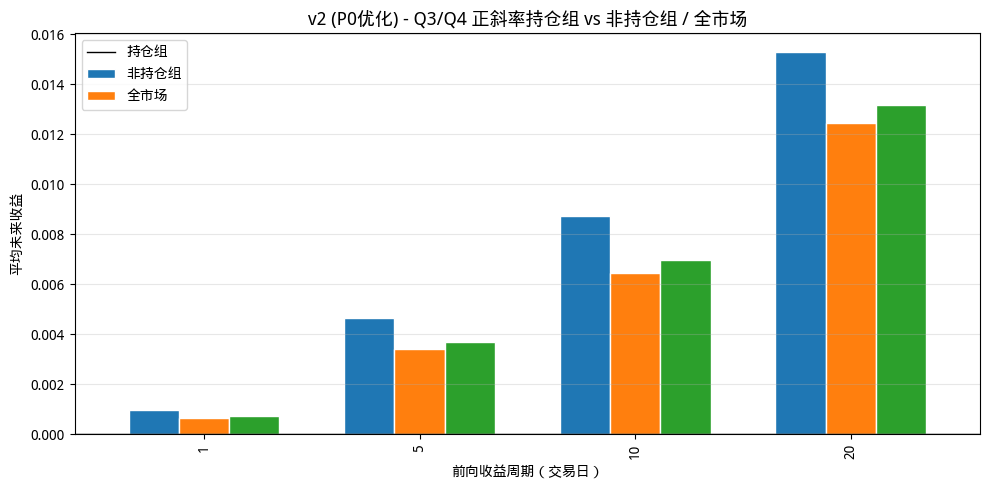

图表已保存。


In [21]:
# ============================================================
# 5.3 分组收益可视化（柱状图对比）
# ============================================================
import matplotlib

matplotlib.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Microsoft YaHei', 'SimHei']  # 按顺序回退  显示中文
# 为了坐标轴负号正常显示。matplotlib默认不支持中文，设置中文字体后，负号会显示异常。需要手动将坐标轴负号设为False才能正常显示负号。
matplotlib.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 5))

plot_df = group_summary_v2[["selected_ret_mean", "unselected_ret_mean", "market_ret_mean"]]
plot_df.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")

ax.set_title("v2 (P0优化) - Q3/Q4 正斜率持仓组 vs 非持仓组 / 全市场", fontsize=13)
ax.set_xlabel("前向收益周期（交易日）")
ax.set_ylabel("平均未来收益")
ax.axhline(0, color="black", linewidth=1)
ax.legend(["持仓组", "非持仓组", "全市场"], loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"v2_group_comparison_bar_w{FACTOR_WINDOW}.png", dpi=150)
plt.show()
print("图表已保存。")


In [22]:
# ============================================================
# 5.4 v1 分组收益汇总（对比基准）
# ============================================================
# 对 v1（仅换手率，无中性化）做同样的分析，方便后面对比。

group_results_v1 = {}
summary_rows_v1 = []

for p, fwd in forward_returns.items():
    daily, spread = calc_group_forward_summary(signal_v1, fwd)
    group_results_v1[p] = daily

    summary_rows_v1.append({
        "period": p,
        "spread_vs_unselected_mean": daily["spread_vs_unselected"].mean(),
        "spread_vs_unselected_t": daily["spread_vs_unselected"].mean()
            / daily["spread_vs_unselected"].std() * np.sqrt(len(daily)),
        "spread_vs_market_mean": daily["spread_vs_market"].mean(),
        "spread_vs_market_t": daily["spread_vs_market"].mean()
            / daily["spread_vs_market"].std() * np.sqrt(len(daily)),
    })

group_summary_v1 = pd.DataFrame(summary_rows_v1).set_index("period")
print("========== v1 因子分组收益汇总（对比基准）==========")
display(group_summary_v1)


========== v1 因子分组收益汇总（对比基准）==========


,spread_vs_unselected_mean,spread_vs_unselected_t,spread_vs_market_mean,spread_vs_market_t
period,,,,
1,0.000458,4.800822,0.000327,4.326091
5,0.001677,8.080560,0.001208,7.391595
10,0.002977,10.276873,0.002096,9.384126
20,0.004149,9.577542,0.002849,8.334484


## 6. IC / Rank IC 分析

计算信号与未来收益的横截面相关性。

- **IC (Pearson)**: signal_factor 与 forward_return 的相关系数
- **Rank IC (Spearman)**: signal_factor 与 forward_return 的秩相关系数

IC > 0 说明选中组收益率更高，IC < 0 说明选中组反而更差。
Rank IC 更稳健，不受极端值影响。


In [23]:
# ============================================================
# 6.1 IC 计算函数
# ============================================================

def rank_corr(a, b):
    """计算 Spearman 秩相关系数。等价于对两个序列各自排序后取 Pearson 相关。"""
    return a.rank().corr(b.rank())


def calc_daily_signal_ic(signal_factor_df, fwd_ret_df):
    """逐日计算 0/1 信号与未来收益的 IC 和 Rank IC。

    Parameters
    ----------
    signal_factor_df : pd.DataFrame, 日期 x 股票，0/1 信号
    fwd_ret_df : pd.DataFrame, 日期 x 股票，未来收益

    Returns
    -------
    pd.DataFrame, 每日的 IC 和 Rank IC
    """
    rows = []
    for dt in signal_factor_df.index.intersection(fwd_ret_df.index):
        df = pd.DataFrame({
            "factor": signal_factor_df.loc[dt],
            "ret": fwd_ret_df.loc[dt]
        }).dropna()

        # 要求当天至少有 30 只股票且信号有两种取值
        if len(df) < 30 or df["factor"].nunique() < 2:
            continue

        rows.append({
            "date": dt,
            "ic": df["factor"].corr(df["ret"]),                # Pearson IC
            "rank_ic": rank_corr(df["factor"], df["ret"]),     # Spearman Rank IC
            "count": len(df),
        })
    return pd.DataFrame(rows).set_index("date")

print("IC 计算函数定义完成。")


IC 计算函数定义完成。


In [24]:
# ============================================================
# 6.2 v2 信号 IC 汇总
# ============================================================

ic_results_v2 = {}
ic_summary_rows_v2 = []

for p, fwd in forward_returns.items():
    ic_df = calc_daily_signal_ic(signal_factor_v2, fwd)
    ic_results_v2[p] = ic_df

    ic_summary_rows_v2.append({
        "period": p,
        "ic_mean": ic_df["ic"].mean(),
        "ic_t": ic_df["ic"].mean() / ic_df["ic"].std() * np.sqrt(len(ic_df)),
        "rank_ic_mean": ic_df["rank_ic"].mean(),
        "rank_ic_t": ic_df["rank_ic"].mean() / ic_df["rank_ic"].std() * np.sqrt(len(ic_df)),
        "rank_ic_pos_ratio": (ic_df["rank_ic"] > 0).mean(),
        "days": len(ic_df),
    })

ic_summary_v2 = pd.DataFrame(ic_summary_rows_v2).set_index("period")

print("========== v2 因子 IC / Rank IC 汇总 ==========")
display(ic_summary_v2)

ic_summary_v2.to_csv(
    OUTPUT_DIR / f"q34_positive_v2_ic_summary_w{FACTOR_WINDOW}.csv",
    encoding="utf-8-sig"
)


========== v2 因子 IC / Rank IC 汇总 ==========


,ic_mean,ic_t,rank_ic_mean,rank_ic_t,rank_ic_pos_ratio,days
period,,,,,,
1,0.004050,3.304163,0.006987,4.569017,0.554018,1518
5,0.008713,7.591153,0.015779,10.949761,0.621532,1514
10,0.011769,10.359780,0.021412,14.912535,0.668655,1509
20,0.011679,9.797485,0.022405,15.221355,0.671781,1499


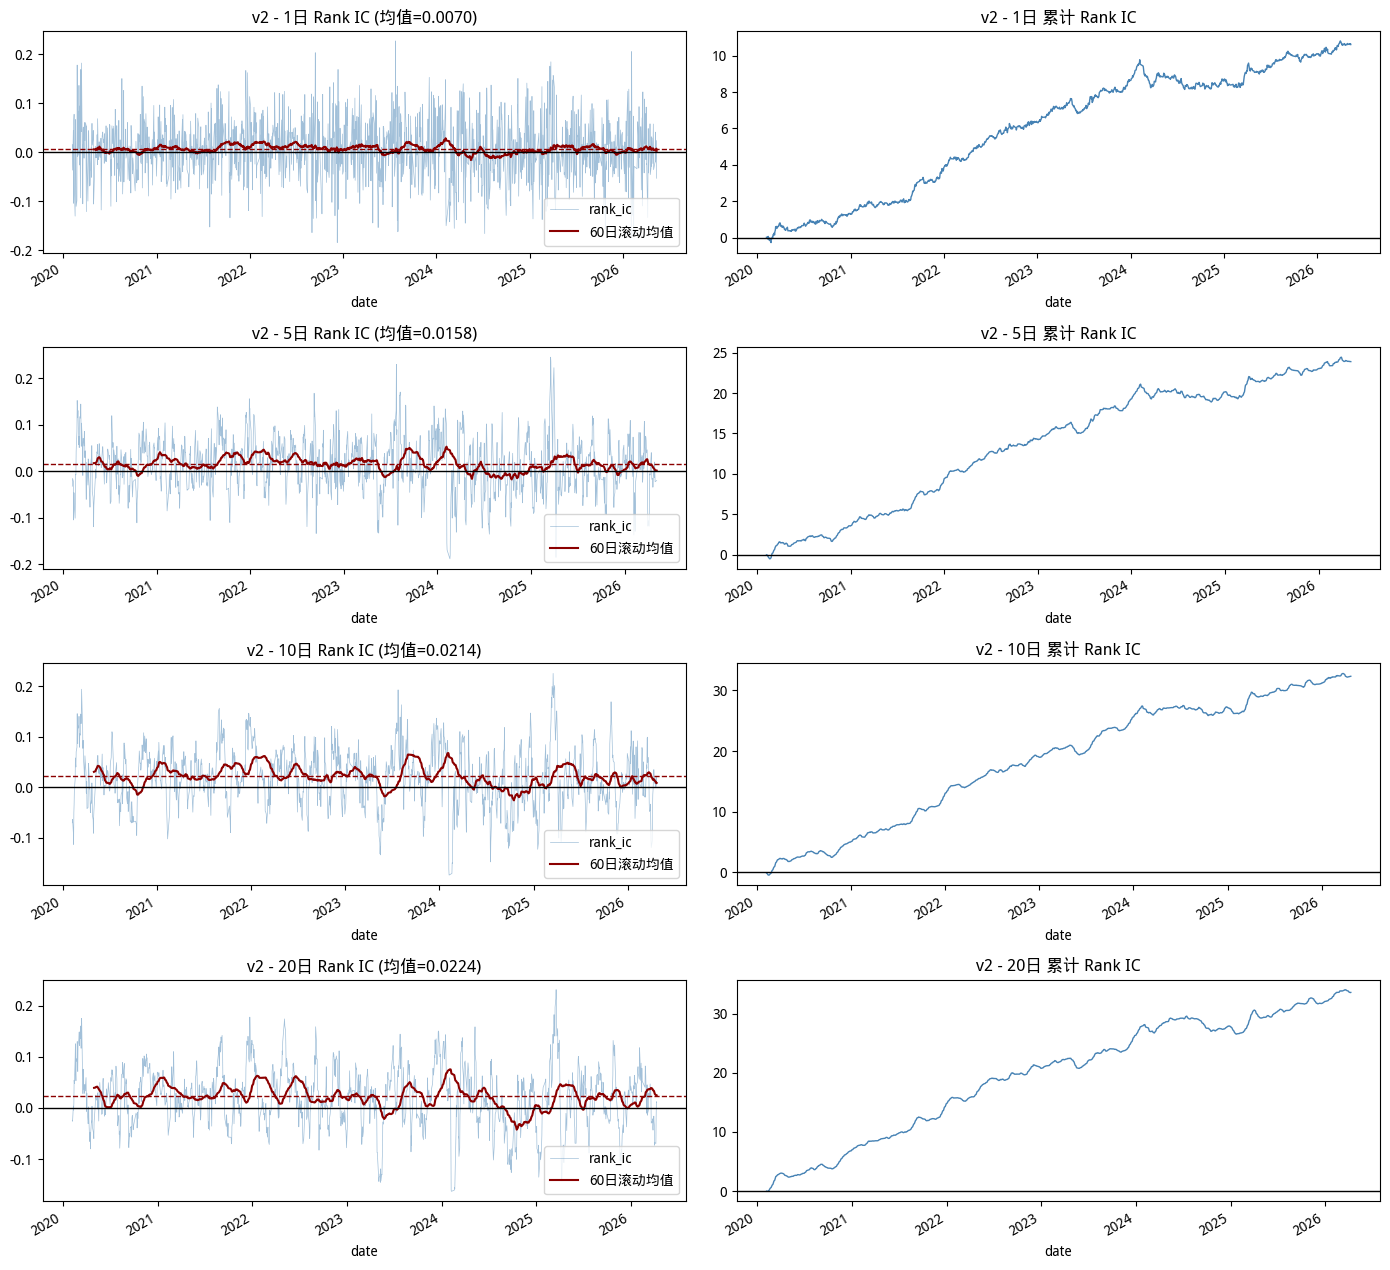

IC 图表已保存。


In [25]:
# ============================================================
# 6.3 IC 可视化（Rank IC 时序 + 累计 IC）
# ============================================================

fig, axes = plt.subplots(len(FORWARD_PERIODS), 2, figsize=(14, 3.2 * len(FORWARD_PERIODS)))
if len(FORWARD_PERIODS) == 1:
    axes = np.array([axes])

for row, p in enumerate(FORWARD_PERIODS):
    ic_df = ic_results_v2[p]

    # 左图：每日 Rank IC 时序
    ax_l = axes[row, 0]
    ic_df["rank_ic"].plot(ax=ax_l, alpha=0.5, linewidth=0.5, color="steelblue")
    ic_df["rank_ic"].rolling(60).mean().plot(
        ax=ax_l, linewidth=1.5, color="darkred", label="60日滚动均值"
    )
    ax_l.set_title(f"v2 - {p}日 Rank IC (均值={ic_df['rank_ic'].mean():.4f})")
    ax_l.axhline(0, color="black", linewidth=1)
    ax_l.axhline(ic_df["rank_ic"].mean(), color="darkred", linestyle="--", linewidth=1)
    ax_l.legend(loc="lower right")

    # 右图：累计 Rank IC
    ax_r = axes[row, 1]
    ic_df["rank_ic"].cumsum().plot(ax=ax_r, linewidth=1, color="steelblue")
    ax_r.set_title(f"v2 - {p}日 累计 Rank IC")
    ax_r.axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"v2_ic_charts_w{FACTOR_WINDOW}.png", dpi=150)
plt.show()
print("IC 图表已保存。")


In [26]:
# ============================================================
# 6.4 v1 信号 IC 汇总（对比基准）
# ============================================================

ic_results_v1 = {}
ic_summary_rows_v1 = []

for p, fwd in forward_returns.items():
    ic_df = calc_daily_signal_ic(signal_factor_v1, fwd)
    ic_results_v1[p] = ic_df

    ic_summary_rows_v1.append({
        "period": p,
        "rank_ic_mean": ic_df["rank_ic"].mean(),
        "rank_ic_t": ic_df["rank_ic"].mean() / ic_df["rank_ic"].std() * np.sqrt(len(ic_df)),
        "rank_ic_pos_ratio": (ic_df["rank_ic"] > 0).mean(),
    })

ic_summary_v1 = pd.DataFrame(ic_summary_rows_v1).set_index("period")
print("========== v1 因子 IC / Rank IC 汇总（对比基准）==========")
display(ic_summary_v1)


========== v1 因子 IC / Rank IC 汇总（对比基准）==========


,rank_ic_mean,rank_ic_t,rank_ic_pos_ratio
period,,,
1,0.015865,9.316670,0.593039
5,0.026124,16.349215,0.653020
10,0.032255,20.360096,0.702357
20,0.034543,21.272702,0.714576


## 7. 年度稳定性分析

观察 v2 优化因子在不同年份的表现是否一致。如果某个年份显著失效，需要警惕该因子在该市场环境下的脆弱性。


========== v2 各年度 Spread vs 非持仓组 ==========


period,1,5,10,20
year,,,,
2020,0.000393,0.001266,0.002277,0.005255
2021,0.000524,0.001953,0.004374,0.005421
2022,0.000572,0.002465,0.003686,0.004436
2023,0.000185,0.001332,0.002423,0.002444
2024,-0.000057,-0.000189,-0.000106,-0.001213
2025,0.000333,0.000745,0.001259,0.001029
2026,0.000068,0.000886,0.001472,0.001898


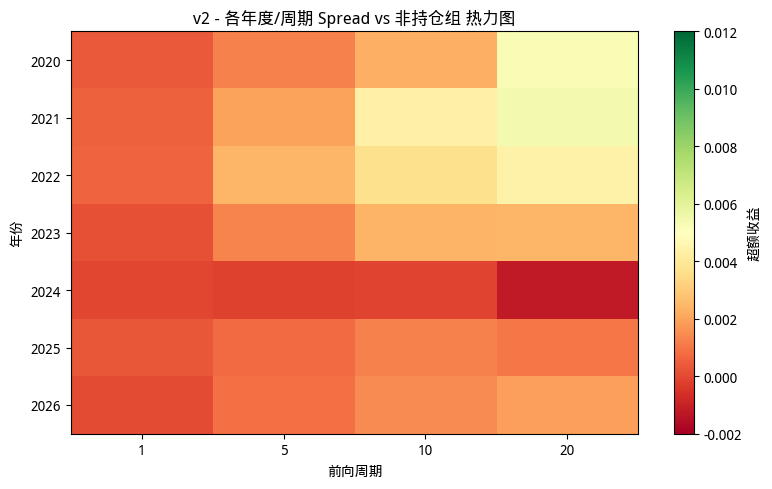

In [27]:
# ============================================================
# 7. 年度稳定性分析
# ============================================================

yearly_rows_v2 = []

for p, daily in group_results_v2.items():
    temp = daily.copy()
    temp["year"] = temp.index.year

    for year, gy in temp.groupby("year"):
        yearly_rows_v2.append({
            "period": p,
            "year": year,
            "selected_ret_mean": gy["selected_ret"].mean(),
            "spread_vs_unselected_mean": gy["spread_vs_unselected"].mean(),
            "spread_vs_unselected_t": gy["spread_vs_unselected"].mean()
                / gy["spread_vs_unselected"].std() * np.sqrt(len(gy)),
            "spread_vs_market_mean": gy["spread_vs_market"].mean(),
            "days": len(gy),
        })

yearly_summary_v2 = pd.DataFrame(yearly_rows_v2)

print("========== v2 各年度 Spread vs 非持仓组 ==========")
pivot_v2 = yearly_summary_v2.pivot(
    index="year", columns="period", values="spread_vs_unselected_mean"
)
display(pivot_v2)

yearly_summary_v2.to_csv(
    OUTPUT_DIR / f"q34_positive_v2_yearly_summary_w{FACTOR_WINDOW}.csv",
    index=False, encoding="utf-8-sig"
)

# 画热力图：年度 x 周期的超额矩阵
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_v2.values, cmap="RdYlGn", aspect="auto", vmin=-0.002, vmax=0.012)
ax.set_xticks(range(len(pivot_v2.columns)))
ax.set_xticklabels(pivot_v2.columns)
ax.set_yticks(range(len(pivot_v2.index)))
ax.set_yticklabels(pivot_v2.index)
ax.set_xlabel("前向周期")
ax.set_ylabel("年份")
ax.set_title("v2 - 各年度/周期 Spread vs 非持仓组 热力图")
plt.colorbar(im, ax=ax, label="超额收益")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"v2_yearly_heatmap_w{FACTOR_WINDOW}.png", dpi=150)
plt.show()


## 8. 覆盖率与换手率诊断

评估 v2 信号的实操可行性：
- **覆盖率**：每天选中的股票够不够形成组合
- **换手率**：信号日间变化大不大（换手率越高，调仓成本越高）


In [28]:
# ============================================================
# 8.1 覆盖率和集合换手率计算
# ============================================================

def calc_set_turnover(signal_df):
    """计算持仓集合的日间换手率。

    set_turnover[t] = 1 - |S_t 交 S_{t-1}| / |S_{t-1}|
    即：上一天持仓中有多少比例今天不再持有。
    """
    previous = None
    rows = []
    for dt in signal_df.index:
        current = set(signal_df.columns[signal_df.loc[dt].fillna(False)])
        if previous is not None and len(previous) > 0:
            overlap = len(current.intersection(previous))
            turnover = 1 - overlap / len(previous)
            rows.append((dt, turnover))
        previous = current
    return pd.Series(dict(rows), name="set_turnover").sort_index()


coverage_v2_ts = signal_v2.sum(axis=1)
coverage_ratio_v2_ts = signal_v2.mean(axis=1)
set_turnover_v2 = calc_set_turnover(signal_v2)

diagnostics_v2 = pd.DataFrame({
    "selected_count": coverage_v2_ts,
    "coverage_ratio": coverage_ratio_v2_ts,
    "set_turnover": set_turnover_v2,
})

print("========== v2 诊断指标汇总 ==========")
display(diagnostics_v2.describe())

diagnostics_v2.to_csv(
    OUTPUT_DIR / f"q34_positive_v2_diagnostics_w{FACTOR_WINDOW}.csv",
    encoding="utf-8-sig"
)


========== v2 诊断指标汇总 ==========


,selected_count,coverage_ratio,set_turnover
count,1538.000000,1538.000000,1518.000000
mean,944.095579,0.184610,0.253528
std,416.945643,0.081530,0.073830
min,0.000000,0.000000,0.083705
25%,648.250000,0.126760,0.203240
50%,923.500000,0.180583,0.241830
75%,1209.750000,0.236557,0.289005
max,2019.000000,0.394799,0.621495


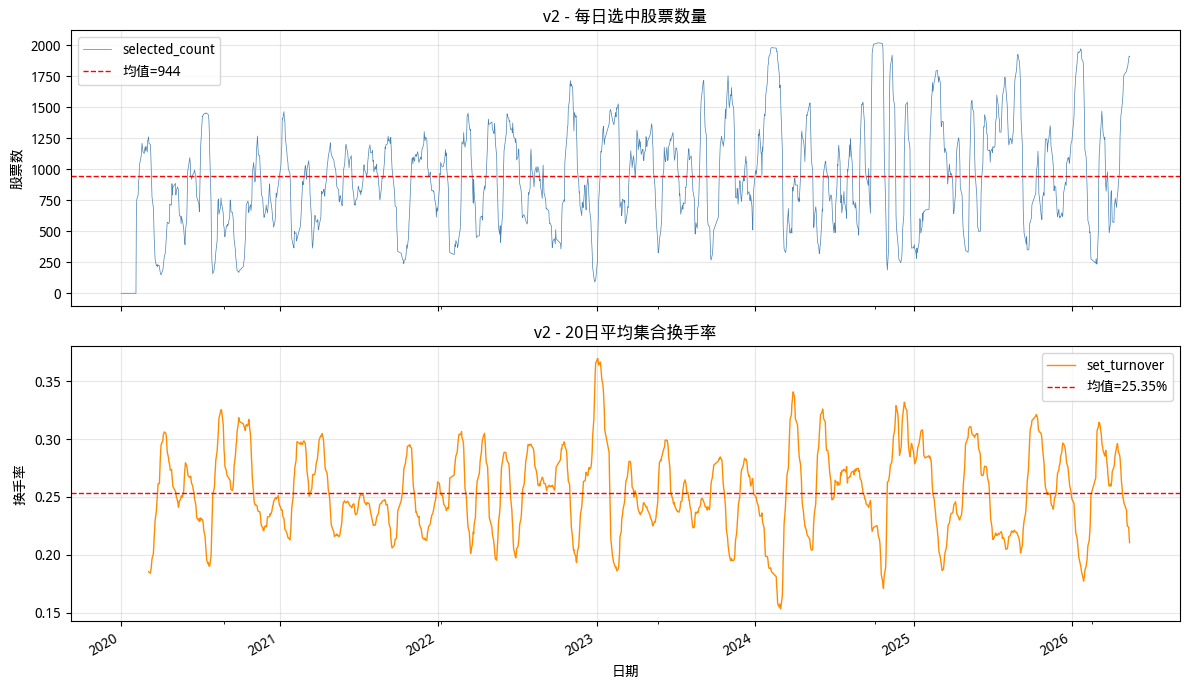

诊断图表已保存。


In [29]:
# ============================================================
# 8.2 诊断指标可视化
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 上图：每日选中股票数量
diagnostics_v2["selected_count"].plot(ax=axes[0], linewidth=0.5, color="steelblue")
axes[0].axhline(diagnostics_v2["selected_count"].mean(),
                color="red", linestyle="--", linewidth=1,
                label=f"均值={diagnostics_v2['selected_count'].mean():.0f}")
axes[0].set_title("v2 - 每日选中股票数量")
axes[0].set_ylabel("股票数")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 下图：20 日滚动平均集合换手率
diagnostics_v2["set_turnover"].rolling(20).mean().plot(
    ax=axes[1], linewidth=1, color="darkorange"
)
axes[1].axhline(diagnostics_v2["set_turnover"].mean(),
                color="red", linestyle="--", linewidth=1,
                label=f"均值={diagnostics_v2['set_turnover'].mean():.2%}")
axes[1].set_title("v2 - 20日平均集合换手率")
axes[1].set_ylabel("换手率")
axes[1].set_xlabel("日期")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"v2_diagnostics_charts_w{FACTOR_WINDOW}.png", dpi=150)
plt.show()
print("诊断图表已保存。")


## 9. 可选：Alphalens factor_data 构造

如 Alphalens 可用，构造 factor_data 供进一步分析（如 tear sheet）。
注意信号是 0/1 二元变量，适合用 bins=2 而非标准分位 tear sheet。


In [30]:
# ============================================================
# 9. Alphalens factor_data 构造（可选）
# ============================================================

if HAS_ALPHALENS:
    # 将宽表 signal_factor 转为 long 格式 Series
    factor_series_v2 = signal_factor_v2.stack(dropna=True)
    factor_series_v2.index = factor_series_v2.index.set_names(["date", "asset"])
    factor_series_v2.name = "q34_positive_signal_v2"

    try:
        factor_data_v2 = al.utils.get_clean_factor_and_forward_returns(
            factor=factor_series_v2,
            prices=close,
            periods=FORWARD_PERIODS,
            quantiles=None,
            bins=2,              # 二元信号用 2 组
            max_loss=0.5,
        )
        print("Alphalens factor_data 构造成功！")
        display(factor_data_v2.head())

        factor_data_v2.to_csv(
            OUTPUT_DIR / f"alphalens_factor_data_q34_positive_v2_w{FACTOR_WINDOW}.csv",
            encoding="utf-8-sig"
        )
    except Exception as exc:
        print("Alphalens factor_data 构造失败，但前面的 Pandas 分析结果已经足够。")
        print(f"失败原因：{type(exc).__name__}: {exc}")
else:
    print("Alphalens 不可用，跳过。")


Dropped 11.0% entries from factor data: 11.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 50.0%, not exceeded: OK!
Alphalens factor_data 构造成功！


1D        5D       10D       20D  factor  factor_quantile
date       asset                                                                       
2020-01-02 000001.XSHE  0.018376 -0.004742 -0.032009 -0.133373     0.0                1
           000002.XSHE -0.015663 -0.011057 -0.062346 -0.155405     0.0                1
           000006.XSHE  0.014815  0.012963 -0.001852 -0.162963     0.0                1
           000007.XSHE -0.004188 -0.011518 -0.024084 -0.207330     0.0                1
           000008.XSHE  0.010782  0.016173 -0.026954 -0.177898     0.0                1

## 10. 新旧因子对比

将 v1（仅换手率）和 v2（换手率 + 行业中性化 + 市值中性化）放到一起比较，
量化 P0 优化的实际改进效果。

同时也列出原始 v0 的数据供参考（从原始 Notebook 结果中手动填入）。


In [31]:
# ============================================================
# 10.1 并排对比表：v0 vs v1 vs v2 关键指标
# ============================================================

comparison_rows = []

# --- v0 原始因子数据（来自 v1 Notebook 的分析结果，手动填入）---
v0_stats = {
    "version": "v0（原始：total_turnover，无中性化）",
    "20D_spread_vs_unselected": 0.005781,
    "20D_spread_t": 13.00,
    "20D_rank_ic": 0.0326,
    "20D_rank_ic_t": 21.42,
    "avg_selected_count": 1112,
    "set_turnover": 0.254,
}
comparison_rows.append(v0_stats)

# --- v1: 仅换手率 ---
v1_stats = {
    "version": "v1（turnover_rate，无中性化）",
    "20D_spread_vs_unselected": group_summary_v1.loc[20, "spread_vs_unselected_mean"],
    "20D_spread_t": group_summary_v1.loc[20, "spread_vs_unselected_t"],
    "20D_rank_ic": ic_summary_v1.loc[20, "rank_ic_mean"],
    "20D_rank_ic_t": ic_summary_v1.loc[20, "rank_ic_t"],
    "avg_selected_count": coverage_v1.mean(),
    "set_turnover": calc_set_turnover(signal_v1).mean(),
}
comparison_rows.append(v1_stats)

# --- v2: 换手率 + 行业中性化 + 市值中性化 ---
v2_stats = {
    "version": "v2（turnover_rate + 行业+市值中性化）",
    "20D_spread_vs_unselected": group_summary_v2.loc[20, "spread_vs_unselected_mean"],
    "20D_spread_t": group_summary_v2.loc[20, "spread_vs_unselected_t"],
    "20D_rank_ic": ic_summary_v2.loc[20, "rank_ic_mean"],
    "20D_rank_ic_t": ic_summary_v2.loc[20, "rank_ic_t"],
    "avg_selected_count": coverage_v2.mean(),
    "set_turnover": set_turnover_v2.mean(),
}
comparison_rows.append(v2_stats)

comparison_df = pd.DataFrame(comparison_rows).set_index("version")

print("========== v0 vs v1 vs v2 - 20日前向收益关键指标对比 ==========")
display(comparison_df)

comparison_df.to_csv(
    OUTPUT_DIR / f"q34_positive_version_comparison_w{FACTOR_WINDOW}.csv",
    encoding="utf-8-sig"
)


========== v0 vs v1 vs v2 - 20日前向收益关键指标对比 ==========


,20D_spread_vs_unselected,20D_spread_t,20D_rank_ic,20D_rank_ic_t,avg_selected_count,set_turnover
version,,,,,,
v0（原始：total_turnover，无中性化）,0.005781,13.000000,0.032600,21.420000,1112.000000,0.254000
v1（turnover_rate，无中性化）,0.004149,9.577542,0.034543,21.272702,1114.737971,0.268868
v2（turnover_rate + 行业+市值中性化）,0.002826,6.878741,0.022405,15.221355,944.095579,0.253528


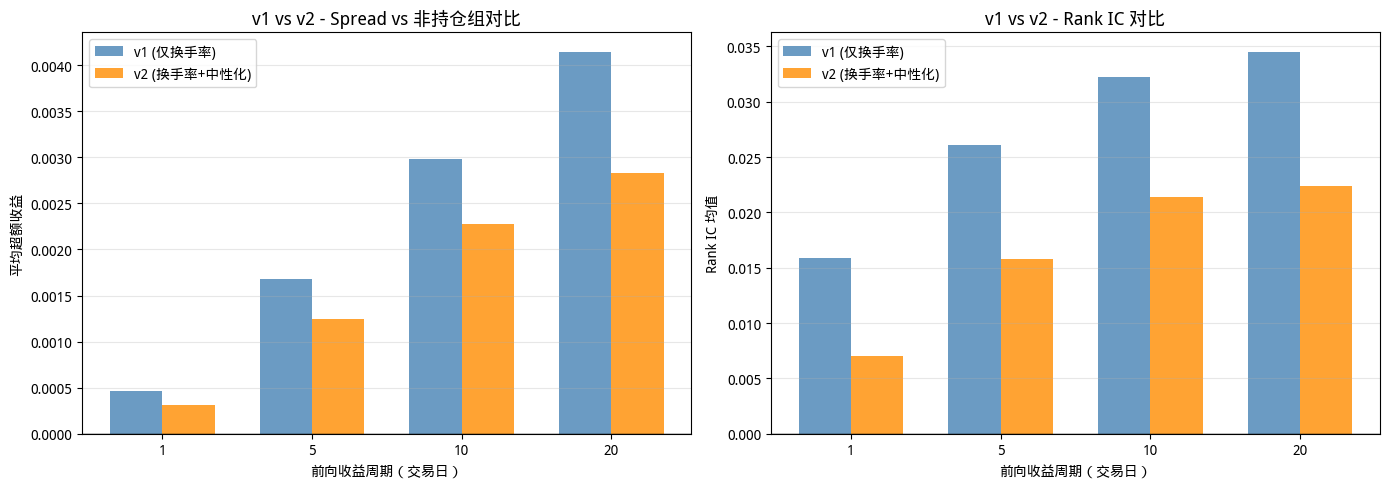

对比图表已保存。


In [32]:
# ============================================================
# 10.2 可视化对比：各周期 Spread 和 Rank IC 并排柱状图
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各周期 Spread vs 非持仓组对比
ax = axes[0]
x = np.arange(len(FORWARD_PERIODS))
width = 0.35

bars1 = ax.bar(x - width/2, group_summary_v1["spread_vs_unselected_mean"],
               width, label="v1 (仅换手率)", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, group_summary_v2["spread_vs_unselected_mean"],
               width, label="v2 (换手率+中性化)", color="darkorange", alpha=0.8)

ax.set_title("v1 vs v2 - Spread vs 非持仓组对比", fontsize=13)
ax.set_xlabel("前向收益周期（交易日）")
ax.set_ylabel("平均超额收益")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in FORWARD_PERIODS])
ax.axhline(0, color="black", linewidth=1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# 右图：各周期 Rank IC 对比
ax = axes[1]
bars3 = ax.bar(x - width/2, ic_summary_v1["rank_ic_mean"],
               width, label="v1 (仅换手率)", color="steelblue", alpha=0.8)
bars4 = ax.bar(x + width/2, ic_summary_v2["rank_ic_mean"],
               width, label="v2 (换手率+中性化)", color="darkorange", alpha=0.8)

ax.set_title("v1 vs v2 - Rank IC 对比", fontsize=13)
ax.set_xlabel("前向收益周期（交易日）")
ax.set_ylabel("Rank IC 均值")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in FORWARD_PERIODS])
ax.axhline(0, color="black", linewidth=1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"v1_vs_v2_comparison_w{FACTOR_WINDOW}.png", dpi=150)
plt.show()
print("对比图表已保存。")


========== 各年度 20日 Spread 对比：v1 vs v2 ==========


,v1_spread,v2_spread,improvement
year,,,
2020,0.007945,0.005255,-0.002690
2021,0.006380,0.005421,-0.000960
2022,0.004118,0.004436,0.000318
2023,0.002739,0.002444,-0.000295
2024,0.004841,-0.001213,-0.006054
2025,0.000191,0.001029,0.000838
2026,0.000972,0.001898,0.000927


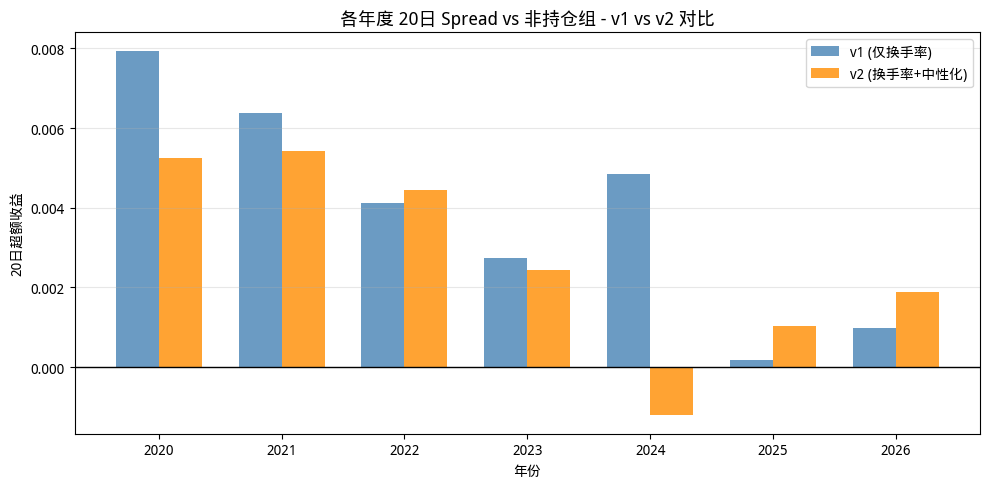

年度对比图表已保存。


In [33]:
# ============================================================
# 10.3 年度稳定性对比
# ============================================================
# 逐年比较 v1 和 v2 的 20 日超额

# v1 年度数据
yearly_rows_v1 = []
for p, daily in group_results_v1.items():
    temp = daily.copy()
    temp["year"] = temp.index.year
    for year, gy in temp.groupby("year"):
        yearly_rows_v1.append({
            "year": year, "period": p,
            "spread": gy["spread_vs_unselected"].mean()
        })

yearly_v1 = pd.DataFrame(yearly_rows_v1)
pivot_yearly_v1 = yearly_v1[yearly_v1["period"] == 20].set_index("year")["spread"]

# v2 年度数据（从之前的 pivot_v2 中获取 20 日列）
pivot_yearly_v2 = pivot_v2[20]

# 并排比较
yearly_compare = pd.DataFrame({
    "v1_spread": pivot_yearly_v1,
    "v2_spread": pivot_yearly_v2,
})
yearly_compare["improvement"] = yearly_compare["v2_spread"] - yearly_compare["v1_spread"]

print("========== 各年度 20日 Spread 对比：v1 vs v2 ==========")
display(yearly_compare)

# 柱状图
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(yearly_compare))
width = 0.35

ax.bar(x - width/2, yearly_compare["v1_spread"], width,
       label="v1 (仅换手率)", color="steelblue", alpha=0.8)
ax.bar(x + width/2, yearly_compare["v2_spread"], width,
       label="v2 (换手率+中性化)", color="darkorange", alpha=0.8)

ax.set_title("各年度 20日 Spread vs 非持仓组 - v1 vs v2 对比", fontsize=13)
ax.set_xlabel("年份")
ax.set_ylabel("20日超额收益")
ax.set_xticks(x)
ax.set_xticklabels(yearly_compare.index.astype(str))
ax.axhline(0, color="black", linewidth=1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"v1_vs_v2_yearly_comparison_w{FACTOR_WINDOW}.png", dpi=150)
plt.show()
print("年度对比图表已保存。")


## 11. 总结：基于真实 RQData / Parquet 的 v2 结果

本次结果已经基于 `data_rq/` 下的真实米筐 Parquet 数据重跑完成，覆盖区间为 **2020-01-01 ~ 2026-05-13**，实际对齐后的交易日为 **2020-01-02 ~ 2026-05-13**，股票数 **5114**。`turnover_rate` 来自 `rqdatac.get_turnover_rate(..., fields="today")`，`market_cap` 来自 `rqdatac.get_factor(..., factor="market_cap")`，不再使用旧 CSV/proxy fallback。

### 数据质量结论

| 检查项 | 最新结果 | 解读 |
|---|---:|---|
| `close` shape | 1538 x 5114 | 与换手率、市值完全对齐 |
| `turnover_rate` shape | 1538 x 5114 | 真实换手率矩阵 |
| `market_cap` shape | 1538 x 5114 | 真实总市值矩阵 |
| `turnover_rate` 负数比例 | 0.0000% | 旧数据中的大量负换手率问题已消除 |
| `market_cap` 负数比例 | 0.0000% | 旧数据中的负市值/伪市值问题已消除 |
| `market_cap` 均值/中位数 | 190.38 亿 / 54.56 亿 | 数量级合理，且均为正 |

结论：当前 v2 的回测结果可以视为基于可信输入数据的结果；之前由 CSV/proxy 数据污染导致的异常结论应废弃。

### 因子构造结论

| 步骤 | 最新结果 | 解读 |
|---|---:|---|
| 原始 `turnover_rate` 斜率均值 | -0.006381 | 量级正常，明显不同于成交额斜率 |
| 原始斜率平均标准差 | 0.213022 | 横截面可比性比 `total_turnover` 更好 |
| 行业中性化跳过天数 | 19 / 1538 | 少量日期因数据不足跳过，可接受 |
| 市值中性化跳过天数 | 19 / 1538 | 与行业中性化一致 |
| 最终中性化残差均值 | -0.002618 | 接近 0 |
| 最终中性化残差标准差 | 0.205492 | 中性化后仍保留有效横截面差异 |
| 最终非空值数量 | 7,000,153 | 样本覆盖充足 |

### v2 绝对表现

v2 信号在 1D、5D、10D、20D 上都为正，且 t 值显著，不再是旧数据下的负结论。

| Period | Spread vs 非持仓组 | t 值 | 正 spread 比例 | Rank IC | Rank IC t | 正 Rank IC 比例 |
|---:|---:|---:|---:|---:|---:|---:|
| 1D | 0.000311 | 3.375 | 54.08% | 0.006987 | 4.569 | 55.40% |
| 5D | 0.001243 | 6.197 | 58.06% | 0.015779 | 10.950 | 62.15% |
| 10D | 0.002279 | 8.225 | 62.29% | 0.021412 | 14.913 | 66.87% |
| 20D | 0.002826 | 6.879 | 61.17% | 0.022405 | 15.221 | 67.18% |

结论：**v2 是正向且统计显著的风险控制版本**。如果目标是验证“换手率斜率在行业、市值中性后是否仍有信息”，答案是有。

### v0 / v1 / v2 横向比较

| Version | 定义 | 20D Spread | Spread t | 20D Rank IC | Rank IC t | 平均持仓数 | 集合换手率 |
|---|---|---:|---:|---:|---:|---:|---:|
| v0 | `total_turnover` 斜率，无中性化 | 0.005781 | 13.000 | 0.032600 | 21.420 | 1112.0 | 25.40% |
| v1 | 真实 `turnover_rate` 斜率，无中性化 | 0.004149 | 9.578 | 0.034543 | 21.273 | 1114.7 | 26.89% |
| v2 | 真实 `turnover_rate` 斜率 + 行业/市值中性化 | 0.002826 | 6.879 | 0.022405 | 15.221 | 944.1 | 25.35% |

横向看，v2 的主要收益是更干净、更风险中性的信号暴露，以及平均持仓数从 v1 的 **1114.7** 降到 **944.1**；集合换手率也从 v1 的 **26.89%** 降到 **25.35%**，接近 v0。

但 alpha 强度被明显压低：20D spread 从 v1 的 **0.004149** 降到 **0.002826**，Rank IC 从 **0.034543** 降到 **0.022405**。这说明原始换手率斜率信号中有相当一部分收益来自行业或市值相关暴露，中性化后保留下来的纯 alpha 仍为正，但更弱。

### 年度稳定性

| Year | v1 20D Spread | v2 20D Spread | v2 - v1 |
|---:|---:|---:|---:|
| 2020 | 0.007945 | 0.005255 | -0.002690 |
| 2021 | 0.006380 | 0.005421 | -0.000960 |
| 2022 | 0.004118 | 0.004436 | 0.000318 |
| 2023 | 0.002739 | 0.002444 | -0.000295 |
| 2024 | 0.004841 | -0.001213 | -0.006054 |
| 2025 | 0.000191 | 0.001029 | 0.000838 |
| 2026 | 0.000972 | 0.001898 | 0.000927 |

v2 在多数年份仍为正，2022、2025、2026 好于 v1；但 2020、2021、2023 弱于 v1，尤其 **2024 年 v2 转负**，是当前版本最需要解释和修复的年份。


## 12. 下一步建议

当前更合理的定位是：**v1 是更强的原始 alpha 版本，v2 是更干净但收益更低的风险控制版本**。如果追求回测收益和 IC，v1 目前更占优；如果追求行业、市值暴露可解释性和组合风控，v2 更适合作为后续组合层的输入。

建议下一轮不要直接否定中性化，而是拆开测试：

1. 只做行业中性化，不做市值中性化，确认收益主要是被哪一步压低。
2. 把市值中性化从完全回归残差改为更柔和的控制，例如分市值组内打分、winsorize 后回归，或仅在组合优化层约束 size exposure。
3. 单独复盘 2024 年，比较 v1 和 v2 的行业/市值暴露变化，确认 v2 转负是市场风格问题、行业分类问题，还是回归残差过度剥离。
4. 保留 Parquet-first 数据链路，后续 notebook 只读取 `data_rq/*.parquet`，避免旧 CSV fallback 再次污染结果。
5. 在策略实现层优先比较 v1、行业中性版、v2 三条曲线，再决定是否推进周频调仓、多窗口斜率合成、连续信号加权等 P1 优化。

一句话结论：**数据问题已经修正；v2 有显著正 alpha，但不是对 v1 的全面改进。它更像一个更干净的低暴露版本，而不是当前最强收益版本。**
